In [18]:
import yfinance as yf
print(yf.Ticker("AAPL").options)

('2026-02-23', '2026-02-25', '2026-02-27', '2026-03-06', '2026-03-13', '2026-03-20', '2026-03-27', '2026-04-02', '2026-04-17', '2026-05-15', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-11-20', '2026-12-18', '2027-01-15', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


Loaded AAPL option chain for expiry 2026-03-13
Spot=264.5800, F0=265.1605, T=0.0548y, r=0.0400
ATM IV (Black) ~ 0.2579

SABR calibration (Hagan lognormal IV fit):
  beta fixed = 0.5
  alpha      = 3.985630
  rho        = -0.257289
  nu         = 2.742701

Miscalibrated SABR params used for hedging:
  alpha_mis = 3.387785
  rho_mis   = -0.107289
  nu_mis    = 3.565512

BS ATM constant vol for hedging: sigma_atm = 0.257913

Hedged option: SHORT 1 call, K=265.0000
Initial premium (MC under true SABR): 6.239224

Hedging P&L: SABR true delta (Hagan IV + Black delta)
  mean: -0.059111
  std :  2.931016
  p01 : -10.673177
  p05 : -4.860250
  p50 :  0.316001
  p95 :  3.419452
  p99 :  4.419687

Hedging P&L: SABR miscalibrated delta (Hagan IV + Black delta)
  mean: -0.057027
  std :  2.978848
  p01 : -11.109129
  p05 : -5.038526
  p50 :  0.429867
  p95 :  3.271890
  p99 :  4.265826

Hedging P&L: BS ATM delta (constant ATM vol)
  mean: -0.060158
  std :  2.932985
  p01 : -10.656609
  p05 : -4.84

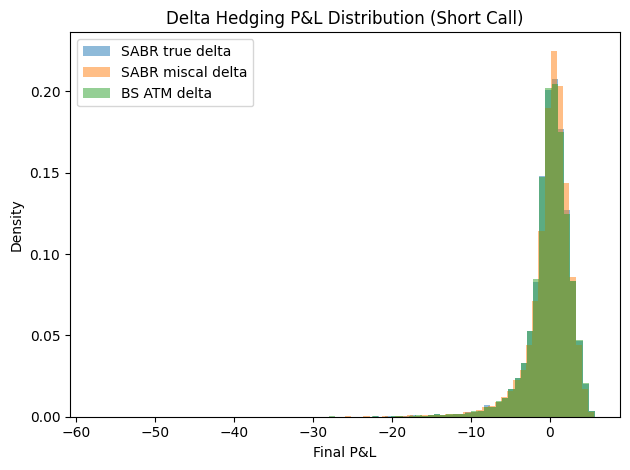

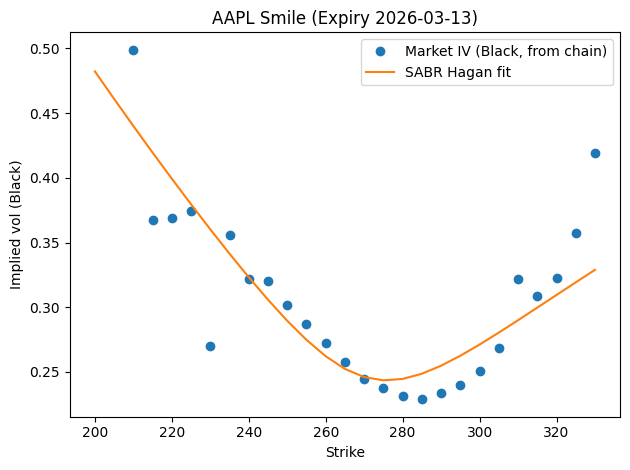

In [19]:
"""
Delta Hedging Error Under Model Mismatch
Reference (true) dynamics: SABR (lognormal) for AAPL forward under Monte Carlo
Hedging deltas from:
  (1) SABR (true params)
  (2) SABR (miscalibrated params)
  (3) Black-Scholes / Black (ATM constant vol)

This script will TRY to fetch AAPL options via yfinance to calibrate SABR (Hagan lognormal vol).
If data fetch fails, it falls back to a synthetic SABR smile.

Copy-paste and run:
  pip install numpy pandas scipy matplotlib yfinance

Notes:
- Uses forward measure (driftless forward) simulation for the option maturity.
- Option pricing for the initial premium is done via Monte Carlo under true SABR dynamics.
- Hedging is discrete (e.g., daily) and self-financing with a cash account accruing at r.
- Delta for SABR hedging is computed as Black(Forward) delta using Hagan implied vol.
- Delta for BS ATM hedging uses constant ATM implied vol from the chain (or synthetic).
"""

import math
import warnings
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import numpy as np
import pandas as pd

from scipy.optimize import brentq, least_squares
from scipy.stats import norm
import matplotlib.pyplot as plt

# Optional live data
try:
    import yfinance as yf
    HAS_YFINANCE = True
except Exception:
    HAS_YFINANCE = False


# -----------------------------
# Utilities: Black / implied vol
# -----------------------------

def black_call_price(F: float, K: float, T: float, r: float, sigma: float) -> float:
    """Black-76 call price on forward F with discount exp(-rT)."""
    if T <= 0:
        return max(F - K, 0.0)
    if sigma <= 0:
        return math.exp(-r * T) * max(F - K, 0.0)

    vol_sqrt = sigma * math.sqrt(T)
    if vol_sqrt < 1e-12:
        return math.exp(-r * T) * max(F - K, 0.0)

    lnFK = math.log(F / K)
    d1 = (lnFK + 0.5 * sigma * sigma * T) / vol_sqrt
    d2 = d1 - vol_sqrt
    return math.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def black_call_delta_forward(F: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    Delta w.r.t forward F for Black-76 call:
      dPrice/dF = exp(-rT) * N(d1)
    """
    if T <= 0:
        return math.exp(-r * T) * (1.0 if F > K else 0.0)
    if sigma <= 0:
        return math.exp(-r * T) * (1.0 if F > K else 0.0)

    vol_sqrt = sigma * math.sqrt(T)
    if vol_sqrt < 1e-12:
        return math.exp(-r * T) * (1.0 if F > K else 0.0)

    lnFK = math.log(F / K)
    d1 = (lnFK + 0.5 * sigma * sigma * T) / vol_sqrt
    return math.exp(-r * T) * norm.cdf(d1)


def implied_vol_black_call(price: float, F: float, K: float, T: float, r: float) -> float:
    """Implied vol under Black-76. Returns NaN if cannot solve."""
    if T <= 0:
        return float("nan")
    disc = math.exp(-r * T)
    intrinsic = disc * max(F - K, 0.0)
    # Basic arbitrage bounds for call on forward:
    # lower: intrinsic, upper: disc*F
    upper = disc * F
    if not (intrinsic - 1e-12 <= price <= upper + 1e-12):
        return float("nan")

    def f(sig):
        return black_call_price(F, K, T, r, sig) - price

    # Try solve on a wide bracket
    try:
        return brentq(f, 1e-8, 5.0, maxiter=200)
    except Exception:
        return float("nan")


# -----------------------------
# SABR (Hagan lognormal approx)
# -----------------------------

def sabr_hagan_lognormal_iv(F: float, K: float, T: float,
                            alpha: float, beta: float, rho: float, nu: float) -> float:
    """
    Hagan et al. (2002) lognormal (Black) implied vol approximation for SABR.
    Assumes F,K > 0, alpha>0, T>=0.
    """
    if T <= 0:
        return 0.0
    if F <= 0 or K <= 0 or alpha <= 0:
        return float("nan")

    # Handle ATM carefully
    if abs(F - K) < 1e-12:
        FK_beta = F ** (1.0 - beta)
        term1 = alpha / FK_beta

        # Higher-order correction (common form)
        A = ((1 - beta) ** 2 / 24.0) * (alpha ** 2) / (F ** (2 - 2 * beta))
        B = (rho * beta * nu * alpha) / (4.0 * (F ** (1 - beta)))
        C = (2 - 3 * rho * rho) * (nu ** 2) / 24.0
        return term1 * (1.0 + (A + B + C) * T)

    lnFK = math.log(F / K)
    one_minus_beta = 1.0 - beta

    FK = F * K
    FK_beta = (FK) ** (one_minus_beta / 2.0)

    z = (nu / alpha) * FK_beta * lnFK
    # x(z)
    sqrt_term = math.sqrt(max(1.0 - 2.0 * rho * z + z * z, 1e-16))
    xz = math.log((sqrt_term + z - rho) / (1.0 - rho))

    # Pre-factors
    # Denominator adjustment
    denom = FK_beta * (1.0 + (one_minus_beta ** 2 / 24.0) * (lnFK ** 2)
                       + (one_minus_beta ** 4 / 1920.0) * (lnFK ** 4))

    # Time correction
    A = ((one_minus_beta) ** 2 / 24.0) * (alpha ** 2) / (FK ** (one_minus_beta))
    B = (rho * beta * nu * alpha) / (4.0 * (FK ** (one_minus_beta / 2.0)))
    C = (2.0 - 3.0 * rho * rho) * (nu ** 2) / 24.0

    # Avoid division by zero
    if abs(xz) < 1e-14:
        return float("nan")

    sigma = (alpha / denom) * (z / xz) * (1.0 + (A + B + C) * T)
    return max(sigma, 0.0)


def calibrate_sabr_hagan(F: float, T: float, strikes: np.ndarray, market_iv: np.ndarray,
                         beta: float = 0.5,
                         bounds: Tuple[Tuple[float, float, float], Tuple[float, float, float]] = (
                             (1e-6, -0.999, 1e-6), (5.0, 0.999, 5.0)
                         ),
                         x0: Optional[np.ndarray] = None) -> Tuple[float, float, float]:
    """
    Calibrate (alpha, rho, nu) to market implied vols using least squares.
    beta fixed.
    """
    strikes = np.asarray(strikes, dtype=float)
    market_iv = np.asarray(market_iv, dtype=float)

    mask = np.isfinite(market_iv) & (market_iv > 1e-6) & np.isfinite(strikes) & (strikes > 0)
    K = strikes[mask]
    iv = market_iv[mask]

    if len(K) < 5:
        raise ValueError("Not enough valid strikes/IVs to calibrate SABR.")

    if x0 is None:
        # crude init
        atm_idx = np.argmin(np.abs(K - F))
        atm_iv = float(iv[atm_idx]) if np.isfinite(iv[atm_idx]) else float(np.nanmean(iv))
        # alpha roughly atm_iv * F^(1-beta)
        alpha0 = max(1e-3, atm_iv * (F ** (1 - beta)))
        rho0 = 0.0
        nu0 = 0.5
        x0 = np.array([alpha0, rho0, nu0], dtype=float)

    lb, ub = np.array(bounds[0], float), np.array(bounds[1], float)

    def residuals(x):
        a, r, n = x
        model = np.array([sabr_hagan_lognormal_iv(F, k, T, a, beta, r, n) for k in K], dtype=float)
        # Weight slightly toward ATM
        w = 1.0 / (0.5 + (np.abs(np.log(K / F)) / 0.15))
        return w * (model - iv)

    res = least_squares(residuals, x0=x0, bounds=(lb, ub), ftol=1e-10, xtol=1e-10, gtol=1e-10, max_nfev=5000)
    a, r, n = res.x
    return float(a), float(r), float(n)


# -----------------------------
# SABR Monte Carlo simulation
# -----------------------------

def simulate_sabr_forward_paths(
    F0: float,
    alpha0: float,
    beta: float,
    rho: float,
    nu: float,
    T: float,
    n_steps: int,
    n_paths: int,
    seed: int = 12345
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simulate SABR forward dynamics (driftless):
      dF = alpha * F^beta dW1
      dalpha = nu * alpha dW2
      corr(dW1,dW2)=rho

    Returns:
      F_paths: shape (n_paths, n_steps+1)
      alpha_paths: shape (n_paths, n_steps+1)
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = math.sqrt(dt)

    F = np.full((n_paths, n_steps + 1), F0, dtype=float)
    a = np.full((n_paths, n_steps + 1), alpha0, dtype=float)

    # Correlated normals
    z1 = rng.standard_normal(size=(n_paths, n_steps))
    z2 = rng.standard_normal(size=(n_paths, n_steps))
    w1 = z1
    w2 = rho * z1 + math.sqrt(max(1.0 - rho * rho, 0.0)) * z2

    for t in range(n_steps):
        Ft = F[:, t]
        at = a[:, t]

        # Keep positivity
        Ft = np.maximum(Ft, 1e-12)
        at = np.maximum(at, 1e-12)

        # Euler
        dF = at * (Ft ** beta) * sqrt_dt * w1[:, t]
        da = nu * at * sqrt_dt * w2[:, t]

        F[:, t + 1] = np.maximum(Ft + dF, 1e-12)
        a[:, t + 1] = np.maximum(at + da, 1e-12)

    return F, a


def sabr_mc_call_price_from_paths(F_T: np.ndarray, K: float, T: float, r: float) -> float:
    payoff = np.maximum(F_T - K, 0.0)
    return float(math.exp(-r * T) * np.mean(payoff))


# -----------------------------
# Data loading (AAPL) + IV extraction
# -----------------------------

@dataclass
class MarketSmile:
    spot: float
    r: float
    T: float
    expiry: str
    strikes: np.ndarray
    call_mid: np.ndarray
    iv_black: np.ndarray
    F0: float
    atm_iv: float


def _pick_expiry_date(ticker: "yf.Ticker", min_days: int = 20, max_days: int = 90) -> str:
    exps = ticker.options
    if not exps:
        raise ValueError("No option expiries returned by yfinance.")
    # pick nearest expiry within [min_days, max_days]
    # yfinance expiry strings are like '2026-03-20'
    today = pd.Timestamp.today(tz=None).normalize()
    cand = []
    for e in exps:
        d = pd.Timestamp(e)
        days = (d - today).days
        if min_days <= days <= max_days:
            cand.append((days, e))
    if not cand:
        # fallback nearest
        d0 = pd.Timestamp(exps[0])
        return exps[0]
    cand.sort(key=lambda x: x[0])
    return cand[0][1]


def load_aapl_smile_from_yfinance(
    symbol: str = "AAPL",
    r: float = 0.04,
    min_days: int = 20,
    max_days: int = 90,
    strike_span: float = 0.25
) -> MarketSmile:
    """
    Fetch spot + one expiry option chain, compute mid call prices and Black implied vols.
    """
    if not HAS_YFINANCE:
        raise RuntimeError("yfinance not installed/available.")

    tk = yf.Ticker(symbol)

    # spot
    hist = tk.history(period="5d")
    if hist.empty:
        raise ValueError("Failed to fetch spot history.")
    spot = float(hist["Close"].iloc[-1])

    expiry = _pick_expiry_date(tk, min_days=min_days, max_days=max_days)
    chain = tk.option_chain(expiry)
    calls = chain.calls.copy()

    # Choose strikes around spot
    lo = (1.0 - strike_span) * spot
    hi = (1.0 + strike_span) * spot
    calls = calls[(calls["strike"] >= lo) & (calls["strike"] <= hi)].copy()
    calls.sort_values("strike", inplace=True)

    if calls.empty:
        raise ValueError("No calls in selected strike range.")

    # mid prices
    bid = calls["bid"].to_numpy(dtype=float)
    ask = calls["ask"].to_numpy(dtype=float)
    last = calls["lastPrice"].to_numpy(dtype=float)
    mid = np.where((bid > 0) & (ask > 0), 0.5 * (bid + ask), last)

    # time to expiry in years
    today = pd.Timestamp.today(tz=None).normalize()
    exp_ts = pd.Timestamp(expiry)
    days = max((exp_ts - today).days, 1)
    T = days / 365.0

    # forward (ignoring dividends, q=0)
    F0 = spot * math.exp(r * T)

    strikes = calls["strike"].to_numpy(dtype=float)
    iv = np.array([implied_vol_black_call(float(p), F0, float(k), T, r) for p, k in zip(mid, strikes)], dtype=float)

    # ATM IV
    atm_idx = int(np.argmin(np.abs(strikes - spot)))
    atm_iv = float(iv[atm_idx]) if np.isfinite(iv[atm_idx]) else float(np.nanmean(iv[np.isfinite(iv)]))

    if not np.isfinite(atm_iv):
        raise ValueError("Could not compute a valid ATM implied vol.")

    return MarketSmile(
        spot=spot, r=r, T=T, expiry=expiry,
        strikes=strikes, call_mid=mid, iv_black=iv, F0=F0, atm_iv=atm_iv
    )


def make_synthetic_smile(
    spot: float = 190.0,
    r: float = 0.04,
    T: float = 30 / 365.0,
    beta: float = 0.5,
    alpha: float = 0.35,
    rho: float = -0.3,
    nu: float = 0.8
) -> MarketSmile:
    """
    Synthetic market smile from SABR Hagan vols + Black prices.
    """
    F0 = spot * math.exp(r * T)
    strikes = np.linspace(0.75 * spot, 1.25 * spot, 21)
    iv = np.array([sabr_hagan_lognormal_iv(F0, k, T, alpha, beta, rho, nu) for k in strikes], dtype=float)
    call_mid = np.array([black_call_price(F0, k, T, r, s) for k, s in zip(strikes, iv)], dtype=float)
    atm_iv = float(iv[np.argmin(np.abs(strikes - spot))])
    return MarketSmile(
        spot=spot, r=r, T=T, expiry="SYNTHETIC",
        strikes=strikes, call_mid=call_mid, iv_black=iv, F0=F0, atm_iv=atm_iv
    )


# -----------------------------
# Hedging simulation
# -----------------------------

@dataclass
class HedgeConfig:
    n_paths: int = 20000
    n_steps: int = 30          # e.g., daily steps for ~1 month
    seed: int = 7

    # Option we hedge
    strike: Optional[float] = None  # if None -> ATM (closest strike)
    option_type: str = "call"       # only call implemented

    # Miscalibration knobs (relative/absolute)
    mis_alpha_mult: float = 0.85
    mis_rho_shift: float = 0.15
    mis_nu_mult: float = 1.30


def hedge_one_path_discrete(
    F_path: np.ndarray,
    K: float,
    r: float,
    T: float,
    model_delta_fn,
    beta: float,
    spot_from_forward_fn
) -> float:
    """
    Self-financing delta hedge (in spot) along one realized path.
    We hedge a SHORT call (sell 1 call), so hedging error is final P&L.
    """
    n_steps = len(F_path) - 1
    dt = T / n_steps

    # Initial time
    t = 0.0
    tau = T - t
    F0 = float(F_path[0])
    S0 = float(spot_from_forward_fn(F0, tau))

    # Initial option premium (we will set outside, but for self-financing we treat it as received cash)
    # We'll compute in the outer routine, so here premium is not used.

    # Start with no stock, cash to be set by caller (premium)
    # We'll return P&L given that caller initializes cash = premium (short option)
    raise NotImplementedError("Use run_hedge_experiment which handles initialization cleanly.")


def run_hedge_experiment(
    smile: MarketSmile,
    beta: float,
    sabr_true: Tuple[float, float, float],    # alpha, rho, nu
    sabr_mis: Tuple[float, float, float],     # alpha, rho, nu
    atm_bs_vol: float,
    cfg: HedgeConfig
) -> Dict[str, np.ndarray]:
    """
    Simulate SABR true paths, price option via MC under true model,
    and compute hedging P&L distributions for three delta models.
    """
    r, T, F0 = float(smile.r), float(smile.T), float(smile.F0)

    # Choose strike
    if cfg.strike is None:
        K = float(smile.strikes[np.argmin(np.abs(smile.strikes - smile.spot))])
    else:
        K = float(cfg.strike)

    alpha_t, rho_t, nu_t = sabr_true
    alpha_m, rho_m, nu_m = sabr_mis

    # Simulate true SABR forward paths
    F_paths, _ = simulate_sabr_forward_paths(
        F0=F0, alpha0=alpha_t, beta=beta, rho=rho_t, nu=nu_t,
        T=T, n_steps=cfg.n_steps, n_paths=cfg.n_paths, seed=cfg.seed
    )

    # MC premium under true dynamics (same simulated terminal distribution)
    premium = sabr_mc_call_price_from_paths(F_paths[:, -1], K=K, T=T, r=r)

    # Convert forward->spot for hedging
    # F_t = S_t * exp(r * (T-t))  => S_t = F_t * exp(-r*(T-t))
    def spot_from_forward(Ft: float, tau: float) -> float:
        return Ft * math.exp(-r * tau)

    # Delta models (return delta in SPOT units)
    def delta_sabr(Ft: float, tau: float, alpha: float, rho: float, nu: float) -> float:
        if tau <= 0:
            # At expiry, delta jumps; use indicator
            St = spot_from_forward(Ft, tau)
            return 1.0 if (Ft > K) else 0.0
        iv = sabr_hagan_lognormal_iv(Ft, K, tau, alpha, beta, rho, nu)
        iv = max(iv, 1e-12)
        dF = black_call_delta_forward(Ft, K, tau, r, iv)   # dPrice/dF
        # dF/dS = exp(r*tau)
        return dF * math.exp(r * tau)

    def delta_bs_atm(Ft: float, tau: float, sigma: float) -> float:
        if tau <= 0:
            return 1.0 if (Ft > K) else 0.0
        sigma = max(float(sigma), 1e-12)
        dF = black_call_delta_forward(Ft, K, tau, r, sigma)
        return dF * math.exp(r * tau)

    # Run hedges
    pnl_true = np.zeros(cfg.n_paths, dtype=float)
    pnl_mis = np.zeros(cfg.n_paths, dtype=float)
    pnl_atm = np.zeros(cfg.n_paths, dtype=float)

    dt = T / cfg.n_steps

    for i in range(cfg.n_paths):
        # Short 1 call: receive premium at t=0
        cash_true = premium
        cash_mis = premium
        cash_atm = premium

        # Stock positions (shares)
        pos_true = 0.0
        pos_mis = 0.0
        pos_atm = 0.0

        for step in range(cfg.n_steps):
            t = step * dt
            tau = T - t
            Ft = float(F_paths[i, step])
            St = float(spot_from_forward(Ft, tau))

            # Accrue cash at r over dt
            cash_true *= math.exp(r * dt)
            cash_mis *= math.exp(r * dt)
            cash_atm *= math.exp(r * dt)

            # Compute target deltas
            d_true = delta_sabr(Ft, tau, alpha_t, rho_t, nu_t)
            d_mis = delta_sabr(Ft, tau, alpha_m, rho_m, nu_m)
            d_atm = delta_bs_atm(Ft, tau, atm_bs_vol)

            # Rebalance: buy/sell shares to reach target delta
            # cost = (new - old) * S
            trade_true = (d_true - pos_true) * St
            trade_mis = (d_mis - pos_mis) * St
            trade_atm = (d_atm - pos_atm) * St

            cash_true -= trade_true
            cash_mis -= trade_mis
            cash_atm -= trade_atm

            pos_true = d_true
            pos_mis = d_mis
            pos_atm = d_atm

        # Maturity
        Ft_T = float(F_paths[i, -1])
        St_T = float(spot_from_forward(Ft_T, 0.0))
        payoff = max(Ft_T - K, 0.0)  # payoff in forward numeraire, but at expiry F_T=S_T (tau=0), so ok

        # Liquidate stock at maturity
        cash_true += pos_true * St_T
        cash_mis += pos_mis * St_T
        cash_atm += pos_atm * St_T

        # Pay option payoff (short call)
        cash_true -= payoff
        cash_mis -= payoff
        cash_atm -= payoff

        pnl_true[i] = cash_true
        pnl_mis[i] = cash_mis
        pnl_atm[i] = cash_atm

    return {
        "premium_mc": np.array([premium]),
        "K": np.array([K]),
        "pnl_sabr_true": pnl_true,
        "pnl_sabr_miscal": pnl_mis,
        "pnl_bs_atm": pnl_atm
    }


def summarize_pnl(x: np.ndarray, name: str) -> None:
    x = np.asarray(x, float)
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1))
    p01 = float(np.quantile(x, 0.01))
    p05 = float(np.quantile(x, 0.05))
    p50 = float(np.quantile(x, 0.50))
    p95 = float(np.quantile(x, 0.95))
    p99 = float(np.quantile(x, 0.99))
    print(f"\n{name}")
    print(f"  mean: {mean: .6f}")
    print(f"  std : {std: .6f}")
    print(f"  p01 : {p01: .6f}")
    print(f"  p05 : {p05: .6f}")
    print(f"  p50 : {p50: .6f}")
    print(f"  p95 : {p95: .6f}")
    print(f"  p99 : {p99: .6f}")


# -----------------------------
# Main
# -----------------------------

def main():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    np.set_printoptions(suppress=True, precision=6)

    # Project knobs
    SYMBOL = "AAPL"
    R = 0.04
    BETA = 0.5

    cfg = HedgeConfig(
        n_paths=20000,   # increase for tighter estimates
        n_steps=30,      # daily-ish
        seed=42,
        strike=None,     # None => ATM strike from chain
        mis_alpha_mult=0.85,
        mis_rho_shift=0.15,
        mis_nu_mult=1.30
    )

    # 1) Load AAPL market smile (or fallback)
    smile = None
    if HAS_YFINANCE:
        try:
            smile = load_aapl_smile_from_yfinance(
                symbol=SYMBOL, r=R, min_days=20, max_days=90, strike_span=0.25
            )
            print(f"Loaded {SYMBOL} option chain for expiry {smile.expiry}")
        except Exception as e:
            print(f"yfinance fetch failed ({e}). Falling back to synthetic smile.")
            smile = make_synthetic_smile(spot=190.0, r=R, T=30/365, beta=BETA, alpha=0.35, rho=-0.3, nu=0.8)
    else:
        print("yfinance not available. Using synthetic smile.")
        smile = make_synthetic_smile(spot=190.0, r=R, T=30/365, beta=BETA, alpha=0.35, rho=-0.3, nu=0.8)

    print(f"Spot={smile.spot:.4f}, F0={smile.F0:.4f}, T={smile.T:.4f}y, r={smile.r:.4f}")
    print(f"ATM IV (Black) ~ {smile.atm_iv:.4f}")

    # 2) Calibrate SABR (alpha, rho, nu) to the smile (Hagan vols)
    # Filter to finite IVs
    mask = np.isfinite(smile.iv_black) & (smile.iv_black > 1e-6)
    strikes_fit = smile.strikes[mask]
    iv_fit = smile.iv_black[mask]

    if len(strikes_fit) >= 5:
        alpha_hat, rho_hat, nu_hat = calibrate_sabr_hagan(
            F=smile.F0, T=smile.T, strikes=strikes_fit, market_iv=iv_fit, beta=BETA
        )
        print("\nSABR calibration (Hagan lognormal IV fit):")
        print(f"  beta fixed = {BETA}")
        print(f"  alpha      = {alpha_hat:.6f}")
        print(f"  rho        = {rho_hat:.6f}")
        print(f"  nu         = {nu_hat:.6f}")
        sabr_true = (alpha_hat, rho_hat, nu_hat)
    else:
        # If we don't have good market IVs, use synthetic-ish params
        print("Not enough valid market IVs; using synthetic SABR params for 'true'.")
        sabr_true = (0.35, -0.30, 0.80)

    # 3) Define miscalibrated SABR params (perturb true)
    alpha_t, rho_t, nu_t = sabr_true
    sabr_mis = (
        max(1e-6, cfg.mis_alpha_mult * alpha_t),
        float(np.clip(rho_t + cfg.mis_rho_shift, -0.999, 0.999)),
        max(1e-6, cfg.mis_nu_mult * nu_t),
    )
    print("\nMiscalibrated SABR params used for hedging:")
    print(f"  alpha_mis = {sabr_mis[0]:.6f}")
    print(f"  rho_mis   = {sabr_mis[1]:.6f}")
    print(f"  nu_mis    = {sabr_mis[2]:.6f}")

    # 4) BS ATM vol model (constant sigma)
    atm_bs_vol = float(smile.atm_iv)
    print(f"\nBS ATM constant vol for hedging: sigma_atm = {atm_bs_vol:.6f}")

    # 5) Run experiment
    out = run_hedge_experiment(
        smile=smile,
        beta=BETA,
        sabr_true=sabr_true,
        sabr_mis=sabr_mis,
        atm_bs_vol=atm_bs_vol,
        cfg=cfg
    )

    premium = float(out["premium_mc"][0])
    K = float(out["K"][0])
    print(f"\nHedged option: SHORT 1 call, K={K:.4f}")
    print(f"Initial premium (MC under true SABR): {premium:.6f}")

    pnl_true = out["pnl_sabr_true"]
    pnl_mis = out["pnl_sabr_miscal"]
    pnl_atm = out["pnl_bs_atm"]

    summarize_pnl(pnl_true, "Hedging P&L: SABR true delta (Hagan IV + Black delta)")
    summarize_pnl(pnl_mis,  "Hedging P&L: SABR miscalibrated delta (Hagan IV + Black delta)")
    summarize_pnl(pnl_atm,  "Hedging P&L: BS ATM delta (constant ATM vol)")

    # 6) Plot distributions
    plt.figure()
    plt.hist(pnl_true, bins=80, alpha=0.5, density=True, label="SABR true delta")
    plt.hist(pnl_mis,  bins=80, alpha=0.5, density=True, label="SABR miscal delta")
    plt.hist(pnl_atm,  bins=80, alpha=0.5, density=True, label="BS ATM delta")
    plt.title("Delta Hedging P&L Distribution (Short Call)")
    plt.xlabel("Final P&L")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 7) (Optional) Show smile fit
    try:
        alpha_hat, rho_hat, nu_hat = sabr_true
        model_iv = np.array([sabr_hagan_lognormal_iv(smile.F0, k, smile.T, alpha_hat, BETA, rho_hat, nu_hat)
                             for k in smile.strikes], dtype=float)
        plt.figure()
        plt.plot(smile.strikes, smile.iv_black, "o", label="Market IV (Black, from chain)")
        plt.plot(smile.strikes, model_iv, "-", label="SABR Hagan fit")
        plt.title(f"{SYMBOL} Smile (Expiry {smile.expiry})" if smile.expiry != "SYNTHETIC" else "Synthetic Smile")
        plt.xlabel("Strike")
        plt.ylabel("Implied vol (Black)")
        plt.legend()
        plt.tight_layout()
        plt.show()
    except Exception:
        pass


if __name__ == "__main__":
    main()